# Modelling and Evaluation: 

## Objective

This notebook evaluates whether the 11 features engineered in Notebook 2 are useful for predicting whether the **next trading day's Barclays closing price is higher than the current day's close**.

The evaluation is designed around the temporal nature of the problem:

- the final 20% of observations are reserved as a **chronological holdout test set**;
- model development uses **expanding-window time-series cross-validation**;
- preprocessing is fitted within each training fold;
- hyperparameters are selected without using the final test period; and
- performance is compared with both a majority-class baseline and a simple **directional-persistence baseline**.

Because upward and non-upward days are both relevant and the classes are approximately balanced, **balanced accuracy** is used as the primary model-selection metric. F1, ROC-AUC and Matthews correlation coefficient (MCC) are reported alongside it to provide a broader view of performance.


## 1. Setup and load the prepared dataset


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
from sklearn.model_selection import (
    train_test_split,
    TimeSeriesSplit,
    GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier

data = pd.read_csv(
    "barclays_model_data.csv",
    index_col="Date",
    parse_dates=True
).sort_index()

print(f"Observations: {len(data):,}")
print(f"Period: {data.index.min().date()} to {data.index.max().date()}")
print(f"Missing values: {data.isna().sum().sum()}")
print(f"Duplicated dates: {data.index.duplicated().sum()}")

data.head()


Observations: 2,505
Period: 2015-01-30 to 2024-12-30
Missing values: 0
Duplicated dates: 0


,Price_to_MA5,Price_to_MA20,MA5_to_MA20,LogReturn,Vol10,Vol20,LagRet_1,LagRet_2,LagRet_3,LagRet_5,RSI14,Target
Date,,,,,,,,,,,,
2015-01-30,-0.014313,0.000342,0.014867,-0.010198,0.014707,0.019852,-0.001267,-0.010918,-0.005414,-0.001028,52.903909,1
2015-02-02,-0.003043,0.007357,0.010432,0.007234,0.012910,0.018295,-0.010198,-0.001267,-0.010918,-0.009919,53.003169,1
2015-02-03,0.042287,0.057088,0.014200,0.052046,0.019620,0.021068,0.007234,-0.010198,-0.001267,-0.005414,74.604749,1
2015-02-04,0.033229,0.054293,0.020387,0.001207,0.019549,0.021067,0.052046,0.007234,-0.010198,-0.010918,72.365602,1
2015-02-05,0.023026,0.051886,0.028210,0.000201,0.018463,0.020315,0.001207,0.052046,0.007234,-0.001267,78.463328,1


## 2. Define predictors and target


In [2]:
features = [
    "Price_to_MA5",
    "Price_to_MA20",
    "MA5_to_MA20",
    "LogReturn",
    "Vol10",
    "Vol20",
    "LagRet_1",
    "LagRet_2",
    "LagRet_3",
    "LagRet_5",
    "RSI14"
]

X = data[features].copy()
y = data["Target"].astype(int).copy()

print("Predictor shape:", X.shape)
print("Target shape:", y.shape)

target_distribution = pd.DataFrame({
    "Count": y.value_counts().sort_index(),
    "Percentage": y.value_counts(normalize=True).sort_index() * 100
})
target_distribution.index = ["No increase (0)", "Increase (1)"]
target_distribution


Predictor shape: (2505, 11)
Target shape: (2505,)


,Count,Percentage
No increase (0),1236,49.341317
Increase (1),1269,50.658683


## 3. Chronological train-test split


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    shuffle=False
)

print(f"Training observations: {len(X_train):,}")
print(f"Test observations:     {len(X_test):,}")

print(
    "\nTraining period:",
    X_train.index.min().date(),
    "to",
    X_train.index.max().date()
)
print(
    "Test period:",
    X_test.index.min().date(),
    "to",
    X_test.index.max().date()
)

print("\nTraining upward-day rate:", f"{y_train.mean():.3f}")
print("Test upward-day rate:    ", f"{y_test.mean():.3f}")


Training observations: 2,004
Test observations:     501

Training period: 2015-01-30 to 2023-01-05
Test period: 2023-01-06 to 2024-12-30

Training upward-day rate: 0.497
Test upward-day rate:     0.547


The earliest 80% of observations are used for model development and the latest 20% are held back for final evaluation. `shuffle=False` is essential: a random split would allow models to learn from observations that occur after observations in the test sample.

## 4. Evaluation Framework and Diagnostic Measures

Before fitting the models, the evaluation measures are defined in the context of predicting the next trading day's Barclays closing-price direction.

For trading day t, the target is

$$
Y_t =
\begin{cases}
1, & \text{if } Close_{t+1} > Close_t, \\
0, & \text{if } Close_{t+1} \leq Close_t.
\end{cases}
$$

Thus, class 1 represents an **upward next-day movement**, while class 0 represents a **non-upward next-day movement**.

The resulting predictions can be summarised using four quantities:

- **True Positive (TP):** Barclays is predicted to go up and does go up.
- **True Negative (TN):** Barclays is predicted not to go up and does not go up.
- **False Positive (FP):** Barclays is predicted to go up but does not go up.
- **False Negative (FN):** Barclays is predicted not to go up but does go up.


### Classification Threshold

Each model produces an estimated probability of an upward next-day movement,

$$
\hat{p}_t = P(Y_t = 1 \mid X_t),
$$

where \(X_t\) contains the predictor information available on trading day \(t\).

To convert this probability into a predicted class, a classification threshold is required. Using the standard threshold of 0.5,

$$
\hat{Y}_t =
\begin{cases}
1, & \text{if } \hat{p}_t \geq 0.5, \\
0, & \text{if } \hat{p}_t < 0.5.
\end{cases}
$$

For example, a predicted probability of 0.62 is classified as an upward movement, while a predicted probability of 0.43 is classified as a downward movement.

These class predictions determine the TP, TN, FP and FN counts used to calculate accuracy, precision, recall, F1-score, balanced accuracy and MCC. Changing the classification threshold can change these counts and therefore the resulting classification metrics.

### Accuracy

Accuracy is the proportion of trading days for which the model correctly predicts the next-day direction:

$$
\text{Accuracy}
=
\frac{TP+TN}{TP+TN+FP+FN}.
$$

It rewards both correctly predicted upward movements and correctly predicted non-upward movements.

### Precision and Recall

Precision measures how often a predicted Barclays price increase is actually followed by an increase:

$$
\text{Precision}
=
\frac{TP}{TP+FP}.
$$

Recall measures how many of the actual Barclays price increases are successfully identified:

$$
\text{Recall}
=
\frac{TP}{TP+FN}.
$$

Therefore, precision measures the reliability of an **upward prediction**, whereas recall measures the model's ability to **detect actual upward movements**.

### F1-score

The F1-score is the harmonic mean of precision and recall:

$$
F_1
=
2
\frac{\text{Precision}\times\text{Recall}}
{\text{Precision}+\text{Recall}}.
$$

A high F1-score therefore requires the model to identify a substantial proportion of actual Barclays price increases without generating too many false upward predictions.

### Balanced Accuracy

Since correctly identifying both upward and non-upward movements is important, balanced accuracy is used as the main classification measure.

Specificity measures the proportion of actual non-upward movements correctly identified:

$$
\text{Specificity}
=
\frac{TN}{TN+FP}.
$$

Balanced accuracy is then

$$
\text{Balanced Accuracy}
=
\frac{1}{2}
\left(
\frac{TP}{TP+FN}
+
\frac{TN}{TN+FP}
\right).
$$

It therefore gives equal weight to the model's ability to identify actual **upward movements** and actual **non-upward movements**.

A balanced accuracy close to 0.5 indicates little ability to distinguish between the two next-day price directions.

### ROC-AUC

The ROC curve evaluates the model over different probability thresholds by comparing the true positive rate

$$
TPR = \frac{TP}{TP+FN}
$$

with the false positive rate

$$
FPR = \frac{FP}{FP+TN}.
$$

ROC-AUC summarises this discrimination across all thresholds. It can be interpreted as

$$
\text{AUC}
=
P(\hat{p}_{up} > \hat{p}_{non-up}).
$$

In this project, this is the probability that the model assigns a higher predicted probability of an increase to an actual Barclays **up day** than to an actual **non-up day**.

An AUC of 0.5 represents chance-level discrimination.

### Matthews Correlation Coefficient

The Matthews correlation coefficient (MCC) uses all four outcomes in the confusion matrix:

$$
\text{MCC}
=
\frac{TP \times TN - FP \times FN}
{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}.
$$

MCC ranges from -1 to 1. A value of 1 represents perfect agreement between predicted and realised Barclays price directions, 0 indicates essentially no association, and -1 represents complete disagreement.

### Evaluation Strategy

Balanced accuracy is used as the **primary model-selection measure** because the aim is to distinguish between upward and non-upward Barclays price movements while giving equal importance to both directions.

Accuracy, precision, recall and F1-score provide additional information about classification behaviour. ROC-AUC evaluates the model's ability to discriminate between upward and non-upward days using predicted probabilities, while MCC provides an overall measure of agreement between predicted and realised price directions.

These measures are first applied to a simple baseline classifier and are then used consistently to evaluate the statistical and machine-learning models.

## 5. Baseline models


In [4]:
def classification_metrics(y_true, y_pred, y_prob=None):
    """Return a consistent set of classification metrics."""
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred)
    }

    if y_prob is not None:
        metrics["ROC-AUC"] = roc_auc_score(y_true, y_prob)
    else:
        metrics["ROC-AUC"] = np.nan

    return metrics


# Baseline 1: always predict the most common training class.
majority_baseline = DummyClassifier(strategy="most_frequent")
majority_baseline.fit(X_train, y_train)
majority_pred = majority_baseline.predict(X_test)

# Baseline 2: directional persistence.
# If today's return is positive, predict an upward next-day close;
# otherwise predict a non-upward next-day close.
persistence_pred = (X_test["LogReturn"] > 0).astype(int).to_numpy()

baseline_results = pd.DataFrame([
    {
        "Model": "Majority Baseline",
        **classification_metrics(y_test, majority_pred)
    },
    {
        "Model": "Persistence Baseline",
        **classification_metrics(y_test, persistence_pred)
    }
]).set_index("Model")

baseline_results.round(3)


,Accuracy,Balanced Accuracy,Precision,Recall,F1,MCC,ROC-AUC
Model,,,,,,,
Majority Baseline,0.453,0.500,0.000,0.000,0.000,0.000,NaN
Persistence Baseline,0.459,0.454,0.505,0.504,0.505,-0.091,NaN


### Baseline interpretation

The **majority baseline** predicts only the most common training class. It therefore achieves **45.3% accuracy**, **50.0% balanced accuracy** and an **F1 score of 0** on the holdout period. The 50% balanced accuracy is exactly what is expected from a classifier that recognises only one of the two classes.

The **persistence baseline** — predicting that tomorrow follows today's direction — produces a higher **F1 score of 50.5%**, but its **balanced accuracy is only 45.4%** and its **MCC is -0.091**. This is an important distinction: F1 alone makes the persistence rule appear relatively competitive because it focuses on the positive class, whereas balanced accuracy and MCC show that its overall directional classification is poor.

These results support using several complementary metrics rather than judging the models from F1 alone.


## 6. Candidate models


In [5]:
log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

xgboost = XGBClassifier(
    n_estimators=200,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

models = {
    "Logistic Regression": log_reg,
    "Random Forest": random_forest,
    "XGBoost": xgboost
}


The models provide increasing flexibility:

- **Logistic Regression** gives a regularised linear benchmark and is fitted inside a scaling pipeline.
- **Random Forest** can represent nonlinear relationships and interactions.
- **XGBoost** builds trees sequentially and can capture more complex nonlinear structure.

The purpose is not to test as many algorithms as possible, but to compare a simple interpretable classifier with two widely used nonlinear ensemble methods.


## 7. Expanding-window time-series cross-validation


In [6]:
tscv = TimeSeriesSplit(n_splits=5)

fold_periods = []

for fold, (train_idx, validation_idx) in enumerate(tscv.split(X_train), start=1):
    fold_periods.append({
        "Fold": fold,
        "Training start": X_train.index[train_idx].min().date(),
        "Training end": X_train.index[train_idx].max().date(),
        "Validation start": X_train.index[validation_idx].min().date(),
        "Validation end": X_train.index[validation_idx].max().date(),
        "Training n": len(train_idx),
        "Validation n": len(validation_idx)
    })

pd.DataFrame(fold_periods)


,Fold,Training start,Training end,Validation start,Validation end,Training n,Validation n
0,1,2015-01-30,2016-05-26,2016-05-27,2017-09-20,334,334
1,2,2015-01-30,2017-09-20,2017-09-21,2019-01-16,668,334
2,3,2015-01-30,2019-01-16,2019-01-17,2020-05-13,1002,334
3,4,2015-01-30,2020-05-13,2020-05-14,2021-09-07,1336,334
4,5,2015-01-30,2021-09-07,2021-09-08,2023-01-05,1670,334


Each validation block occurs strictly after its corresponding training block. As the folds progress, the training window expands to include more historical observations.

This is a closer approximation to the real forecasting process than ordinary shuffled \(k\)-fold cross-validation.


## 8. Untuned cross-validation performance


In [7]:
cv_results = []

for model_name, model in models.items():

    for fold, (train_idx, validation_idx) in enumerate(
        tscv.split(X_train), start=1
    ):
        X_fold_train = X_train.iloc[train_idx]
        X_fold_validation = X_train.iloc[validation_idx]
        y_fold_train = y_train.iloc[train_idx]
        y_fold_validation = y_train.iloc[validation_idx]

        fold_model = clone(model)
        fold_model.fit(X_fold_train, y_fold_train)

        predictions = fold_model.predict(X_fold_validation)
        probabilities = fold_model.predict_proba(X_fold_validation)[:, 1]

        metrics = classification_metrics(
            y_fold_validation,
            predictions,
            probabilities
        )

        cv_results.append({
            "Model": model_name,
            "Fold": fold,
            **metrics
        })

cv_results = pd.DataFrame(cv_results)
cv_results.round(3)


,Model,Fold,Accuracy,Balanced Accuracy,Precision,Recall,F1,MCC,ROC-AUC
0,Logistic Regression,1,0.524,0.533,0.592,0.244,0.346,0.080,0.550
1,Logistic Regression,2,0.473,0.470,0.437,0.230,0.302,-0.068,0.453
2,Logistic Regression,3,0.527,0.525,0.519,0.423,0.466,0.050,0.512
3,Logistic Regression,4,0.506,0.509,0.528,0.434,0.476,0.018,0.532
4,Logistic Regression,5,0.524,0.522,0.507,0.466,0.485,0.044,0.527
5,Random Forest,1,0.524,0.526,0.546,0.448,0.492,0.053,0.540
6,Random Forest,2,0.506,0.505,0.500,0.418,0.455,0.010,0.483
7,Random Forest,3,0.563,0.563,0.552,0.558,0.555,0.126,0.548
8,Random Forest,4,0.509,0.512,0.532,0.428,0.474,0.024,0.527
9,Random Forest,5,0.467,0.468,0.452,0.497,0.473,-0.064,0.487


In [8]:
cv_summary = (
    cv_results
    .groupby("Model")
    .agg(
        Mean_Balanced_Accuracy=("Balanced Accuracy", "mean"),
        SD_Balanced_Accuracy=("Balanced Accuracy", "std"),
        Mean_F1=("F1", "mean"),
        SD_F1=("F1", "std"),
        Mean_ROC_AUC=("ROC-AUC", "mean"),
        Mean_MCC=("MCC", "mean")
    )
    .sort_values("Mean_Balanced_Accuracy", ascending=False)
)

cv_summary.round(3)


,Mean_Balanced_Accuracy,SD_Balanced_Accuracy,Mean_F1,SD_F1,Mean_ROC_AUC,Mean_MCC
Model,,,,,,
Random Forest,0.515,0.034,0.490,0.038,0.517,0.030
Logistic Regression,0.512,0.025,0.415,0.085,0.515,0.025
XGBoost,0.501,0.037,0.476,0.044,0.523,0.002


### Cross-validation interpretation

Before tuning, none of the three models shows strong discrimination. Mean balanced accuracy is **0.515 for Random Forest**, **0.512 for Logistic Regression** and **0.501 for XGBoost** — all close to the 0.50 chance reference.

The corresponding mean ROC-AUC values are also weak: approximately **0.517, 0.515 and 0.523** respectively. This suggests that the models have little ability to consistently rank upward days above non-upward days during the training-era validation folds.

The variation between folds is also relevant. Performance is not uniformly above chance across historical periods, so there is no strong evidence at this stage that the engineered technical features contain a stable predictive relationship. Hyperparameter tuning is therefore used to test whether modest improvements are possible, rather than because the untuned models already show a strong signal.


## 9. Hyperparameter tuning


In [9]:
parameter_grids = {
    "Logistic Regression": {
        "logistic_regression__C": [0.01, 0.1, 1, 10]
    },
    "Random Forest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 5, 10],
        "min_samples_leaf": [1, 5, 10]
    },
    "XGBoost": {
        "n_estimators": [100, 200, 300],
        "max_depth": [2, 3, 5],
        "learning_rate": [0.01, 0.05, 0.1]
    }
}

tuned_models = {}
tuning_results = []

for model_name, model in models.items():
    print(f"Tuning {model_name}...")

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=parameter_grids[model_name],
        scoring={
            "balanced_accuracy": "balanced_accuracy",
            "f1": "f1",
            "roc_auc": "roc_auc"
        },
        refit="balanced_accuracy",
        cv=tscv,
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)
    tuned_models[model_name] = grid_search.best_estimator_

    parameter_text = ", ".join(
        f"{parameter.split('__')[-1]}={value}"
        for parameter, value in grid_search.best_params_.items()
    )

    best_idx = grid_search.best_index_

    tuning_results.append({
        "Model": model_name,
        "Best CV Balanced Accuracy":
            grid_search.cv_results_["mean_test_balanced_accuracy"][best_idx],
        "CV F1 at Selected Parameters":
            grid_search.cv_results_["mean_test_f1"][best_idx],
        "CV ROC-AUC at Selected Parameters":
            grid_search.cv_results_["mean_test_roc_auc"][best_idx],
        "Selected Hyperparameters": parameter_text
    })

tuning_results = pd.DataFrame(tuning_results).set_index("Model")
tuning_results.round(3)


Tuning Logistic Regression...
Tuning Random Forest...
Tuning XGBoost...


,Best CV Balanced Accuracy,CV F1 at Selected Parameters,CV ROC-AUC at Selected Parameters,Selected Hyperparameters
Model,,,,
Logistic Regression,0.515,0.373,0.528,C=0.01
Random Forest,0.520,0.494,0.524,"max_depth=10, min_samples_leaf=1, n_estimators..."
XGBoost,0.530,0.501,0.529,"learning_rate=0.1, max_depth=3, n_estimators=100"


### Tuning interpretation

The selected models achieve cross-validated balanced accuracies of approximately **0.515 for Logistic Regression**, **0.520 for Random Forest** and **0.530 for XGBoost**.

XGBoost therefore has the strongest tuned cross-validation result, but the absolute differences are small and all three scores remain close to 0.50. The tuning results should consequently be interpreted cautiously: they identify the parameter settings that worked best within the historical training period, not evidence that any model has established reliable future predictability.

The chronological holdout period is the more important test of whether these relationships generalise.


## 10. Final holdout evaluation


In [10]:
test_results = []
test_predictions = {}
test_probabilities = {}

for model_name, model in tuned_models.items():
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    test_predictions[model_name] = predictions
    test_probabilities[model_name] = probabilities

    test_results.append({
        "Model": model_name,
        **classification_metrics(y_test, predictions, probabilities)
    })

# Add both non-ML baselines to the same comparison.
test_results.extend([
    {
        "Model": "Majority Baseline",
        **classification_metrics(y_test, majority_pred)
    },
    {
        "Model": "Persistence Baseline",
        **classification_metrics(y_test, persistence_pred)
    }
])

test_results = (
    pd.DataFrame(test_results)
    .set_index("Model")
    .sort_values("Balanced Accuracy", ascending=False)
)

test_results.round(3)


,Accuracy,Balanced Accuracy,Precision,Recall,F1,MCC,ROC-AUC
Model,,,,,,,
Random Forest,0.497,0.502,0.549,0.449,0.494,0.004,0.501
Majority Baseline,0.453,0.500,0.000,0.000,0.000,0.000,NaN
Logistic Regression,0.479,0.498,0.544,0.296,0.383,-0.004,0.486
XGBoost,0.471,0.474,0.519,0.445,0.479,-0.052,0.480
Persistence Baseline,0.459,0.454,0.505,0.504,0.505,-0.091,NaN


### Holdout interpretation

The later 2023–2024 holdout period provides a much stricter test of generalisation. **Random Forest records the highest balanced accuracy at 0.502**, with **ROC-AUC 0.501** and **MCC 0.004**. All three values are essentially at chance level.

Logistic Regression is similarly weak, with **0.498 balanced accuracy**, **0.486 ROC-AUC** and **-0.004 MCC**. XGBoost performs worst despite having the strongest tuned cross-validation score: its holdout balanced accuracy falls to **0.474**, ROC-AUC to **0.480**, and MCC to **-0.052**.

The F1 scores tell a slightly different story — **0.494 for Random Forest, 0.479 for XGBoost and 0.383 for Logistic Regression** — but this does not overturn the broader result. In fact, the simple persistence baseline obtains an F1 of **0.505**, higher than all three ML models, while still having poor balanced accuracy and MCC.

Taken together, the holdout metrics provide **no convincing evidence that these models discriminate next-day direction better than chance on later data**.


## 11. Confusion matrices


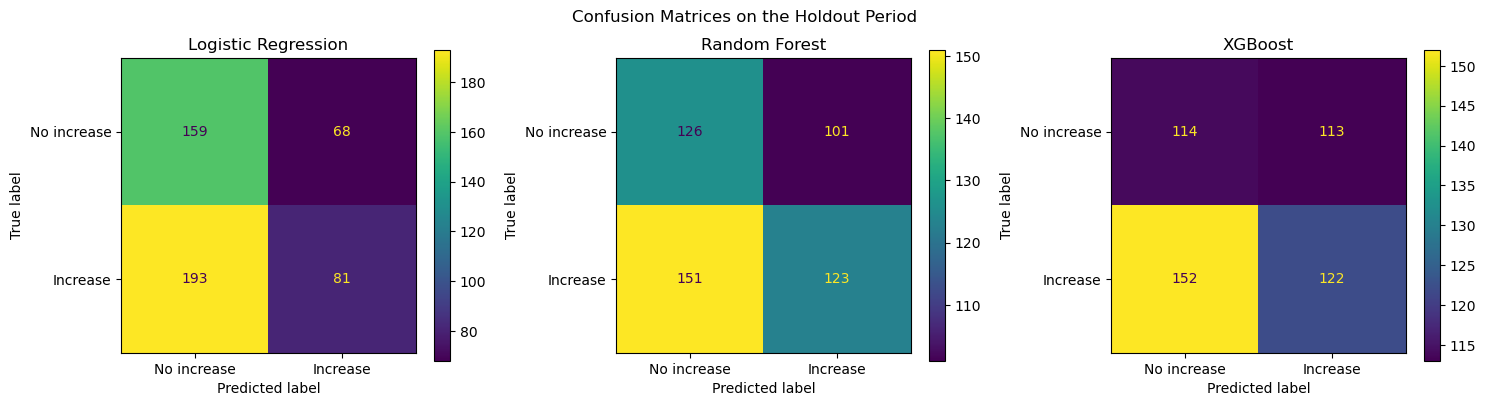

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (model_name, predictions) in zip(
    axes,
    test_predictions.items()
):
    cm = confusion_matrix(y_test, predictions)

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No increase", "Increase"]
    ).plot(
        ax=ax,
        colorbar=True
    )

    ax.set_title(model_name)

plt.suptitle("Confusion Matrices on the Holdout Period")
plt.tight_layout()
plt.show()


### Confusion-matrix interpretation

The confusion matrices help visualise the differences in the summary metrics. The models do not make errors in the same way. Logistic Regression is relatively conservative in predicting the positive class, which contributes to its lower holdout recall and F1. The tree-based models predict upward movements more frequently than Logistic Regression, but still make substantial errors across both classes, contributing to their low balanced accuracies. 


## 12. ROC curves


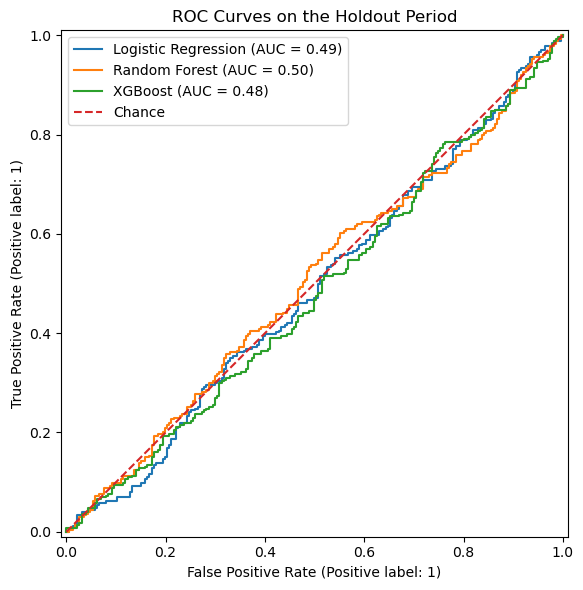

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))

for model_name, model in tuned_models.items():
    RocCurveDisplay.from_predictions(
        y_test,
        test_probabilities[model_name],
        name=model_name,
        ax=ax
    )

ax.plot([0, 1], [0, 1], linestyle="--", label="Chance")
ax.set_title("ROC Curves on the Holdout Period")
ax.legend()
plt.tight_layout()
plt.show()


### ROC interpretation

The ROC curves reinforce the holdout results. Random Forest's **ROC-AUC of 0.501** is effectively indistinguishable from random ranking, while Logistic Regression (**0.486**) and XGBoost (**0.480**) are slightly below the 0.50 reference.

This matters because ROC-AUC evaluates the models across classification thresholds rather than only at the default 0.5 cutoff. The weak values therefore suggest that changing the decision threshold alone would not uncover strong underlying separation between upward and non-upward days.


## 13. Performance through time


,Model,Year,Accuracy,Balanced Accuracy,F1,MCC
0,Logistic Regression,2023,0.484,0.491,0.407,-0.018
1,Logistic Regression,2024,0.474,0.509,0.357,0.021
2,Random Forest,2023,0.504,0.506,0.494,0.012
3,Random Forest,2024,0.490,0.499,0.494,-0.003
4,XGBoost,2023,0.472,0.473,0.470,-0.054
5,XGBoost,2024,0.470,0.475,0.489,-0.051


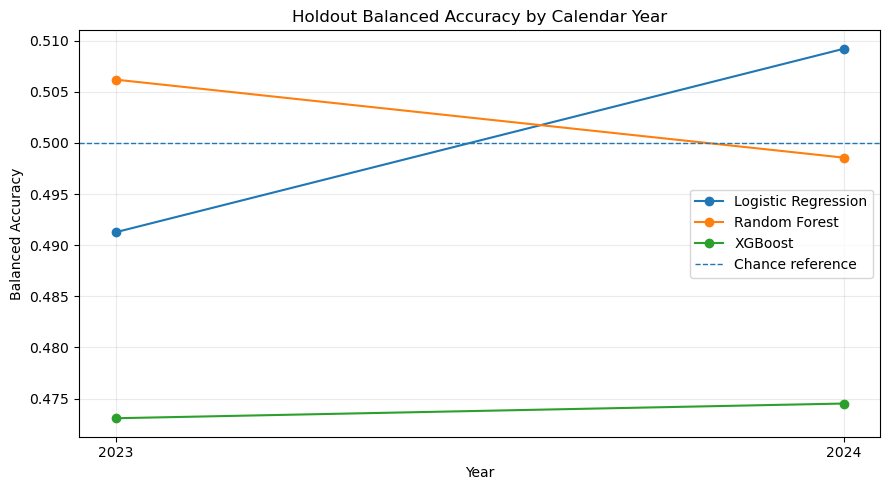

In [13]:
temporal_results = []

for model_name, predictions in test_predictions.items():
    prediction_series = pd.Series(
        predictions,
        index=y_test.index,
        name="Prediction"
    )

    for year in sorted(y_test.index.year.unique()):
        mask = y_test.index.year == year

        temporal_results.append({
            "Model": model_name,
            "Year": year,
            **classification_metrics(
                y_test.loc[mask],
                prediction_series.loc[mask]
            )
        })

temporal_results = pd.DataFrame(temporal_results)

display(
    temporal_results[
        ["Model", "Year", "Accuracy", "Balanced Accuracy", "F1", "MCC"]
    ].round(3)
)

fig, ax = plt.subplots(figsize=(9, 5))

for model_name in temporal_results["Model"].unique():
    subset = temporal_results[temporal_results["Model"] == model_name]
    ax.plot(
        subset["Year"],
        subset["Balanced Accuracy"],
        marker="o",
        label=model_name
    )

ax.axhline(0.5, linestyle="--", linewidth=1, label="Chance reference")
ax.set(
    title="Holdout Balanced Accuracy by Calendar Year",
    xlabel="Year",
    ylabel="Balanced Accuracy"
)
ax.set_xticks(sorted(temporal_results["Year"].unique()))
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


### Temporal-stability interpretation

Splitting the holdout period by year does not reveal a hidden period of strong performance. Random Forest records balanced accuracy of approximately **0.506 in 2023** and **0.499 in 2024**, remaining close to chance in both years. Logistic Regression moves from roughly **0.491 to 0.509**, while XGBoost remains below 0.50 in both years at approximately **0.473 and 0.475**.

The key result is therefore not that performance collapses in one particular holdout year. Rather, **the engineered features show little out-of-sample discriminatory power in either 2023 or 2024**. This makes the weak aggregate holdout result less likely to be explained by a single unusually difficult calendar year.


## 14. Post-hoc permutation importance


In [14]:
# IMPORTANT:
# This is a post-hoc interpretation of the already evaluated holdout set.
# It is not used to select features, retune models or claim a new unbiased
# performance estimate.

permutation_results = {}

for model_name, model in tuned_models.items():
    result = permutation_importance(
        model,
        X_test,
        y_test,
        scoring="balanced_accuracy",
        n_repeats=30,
        random_state=42,
        n_jobs=-1
    )

    permutation_results[model_name] = (
        pd.DataFrame({
            "Feature": features,
            "Importance": result.importances_mean,
            "SD": result.importances_std
        })
        .sort_values("Importance", ascending=True)
    )

for model_name, result_df in permutation_results.items():
    print(f"\n{model_name}")
    display(result_df.sort_values("Importance", ascending=False).round(4))



Logistic Regression


,Feature,Importance,SD
9,LagRet_5,0.0189,0.0096
10,RSI14,0.0136,0.0124
4,Vol10,0.0130,0.0100
8,LagRet_3,0.0047,0.0068
0,Price_to_MA5,0.0045,0.0093
6,LagRet_1,0.0005,0.0043
2,MA5_to_MA20,-0.0005,0.0066
3,LogReturn,-0.0005,0.0045
5,Vol20,-0.0021,0.0025
1,Price_to_MA20,-0.0025,0.0035



Random Forest


,Feature,Importance,SD
6,LagRet_1,0.0161,0.0123
10,RSI14,0.0114,0.0151
2,MA5_to_MA20,0.0009,0.0102
1,Price_to_MA20,-0.0029,0.0143
4,Vol10,-0.0037,0.0117
7,LagRet_2,-0.0047,0.0115
9,LagRet_5,-0.0054,0.0106
5,Vol20,-0.0058,0.0101
0,Price_to_MA5,-0.0084,0.0106
3,LogReturn,-0.0123,0.0126



XGBoost


,Feature,Importance,SD
6,LagRet_1,0.0006,0.0127
1,Price_to_MA20,-0.0025,0.0179
9,LagRet_5,-0.0033,0.0117
10,RSI14,-0.0101,0.0106
7,LagRet_2,-0.0107,0.0144
3,LogReturn,-0.0118,0.0089
4,Vol10,-0.0119,0.0082
8,LagRet_3,-0.0119,0.0105
0,Price_to_MA5,-0.0208,0.0098
5,Vol20,-0.0246,0.0102


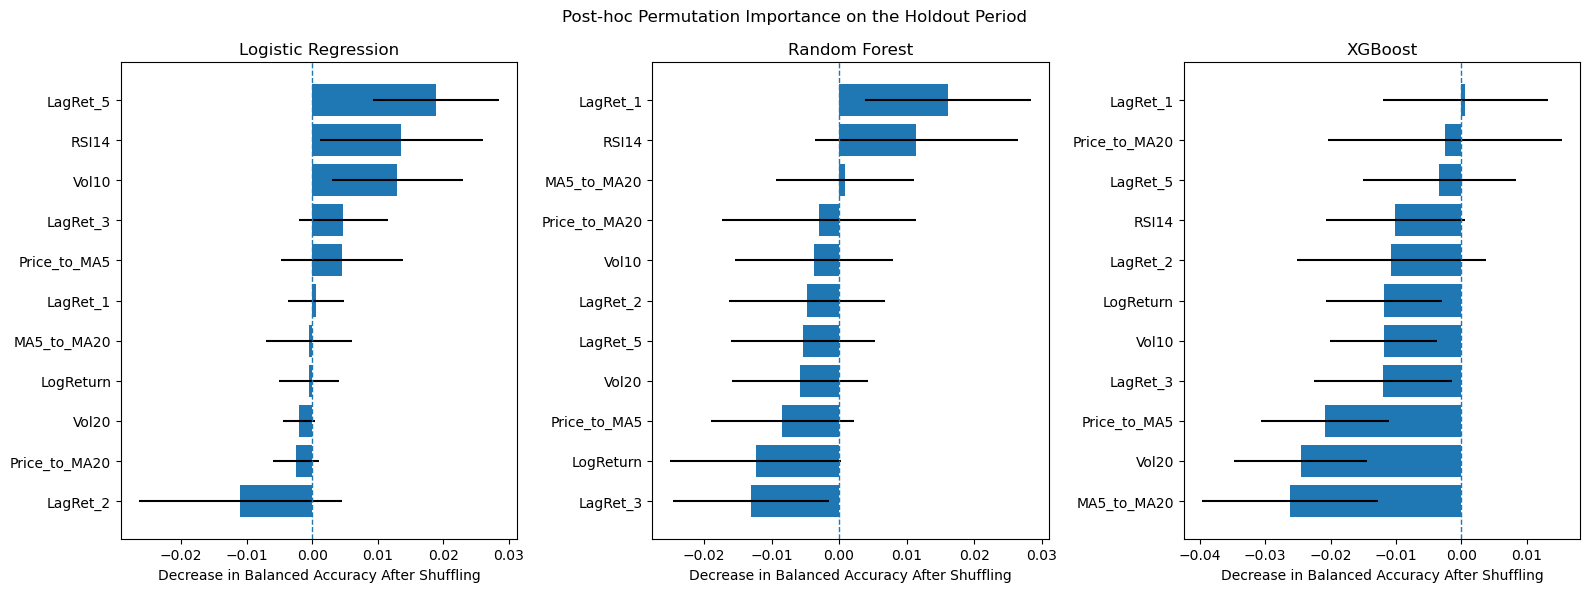

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, (model_name, result_df) in zip(
    axes,
    permutation_results.items()
):
    ax.barh(
        result_df["Feature"],
        result_df["Importance"],
        xerr=result_df["SD"]
    )
    ax.axvline(0, linestyle="--", linewidth=1)
    ax.set_title(model_name)
    ax.set_xlabel("Decrease in Balanced Accuracy After Shuffling")

plt.suptitle("Post-hoc Permutation Importance on the Holdout Period")
plt.tight_layout()
plt.show()


### Permutation-importance interpretation

The permutation results do not identify a strong, consistent predictive driver. For Logistic Regression, the largest mean decrease in balanced accuracy is only about **0.019 for `LagRet_5`**; for Random Forest it is about **0.016 for `LagRet_1`**. XGBoost's importances are predominantly close to zero or negative.

These magnitudes should not be over-interpreted. The underlying holdout performance of all three models is already close to chance, so a feature appearing at the top of a permutation ranking does **not** establish that it contains a reliable economic or predictive signal. Correlation between related trend and volatility variables can also distribute importance across predictors.

The most defensible interpretation is therefore that the importance analysis **reinforces the absence of a strong, stable signal**, rather than identifying a small set of genuinely powerful predictors. Because this analysis uses the final holdout set, it is treated as post-hoc interpretation only and is not used for further feature selection or retuning.


## 15. Cross-validation versus holdout stability


In [16]:
cv_vs_test = (
    tuning_results[
        ["Best CV Balanced Accuracy"]
    ]
    .join(
        test_results[["Balanced Accuracy"]],
        how="left"
    )
    .rename(columns={
        "Balanced Accuracy": "Holdout Balanced Accuracy"
    })
)

cv_vs_test["Difference (Holdout - CV)"] = (
    cv_vs_test["Holdout Balanced Accuracy"]
    - cv_vs_test["Best CV Balanced Accuracy"]
)

cv_vs_test.round(3)


,Best CV Balanced Accuracy,Holdout Balanced Accuracy,Difference (Holdout - CV)
Model,,,
Logistic Regression,0.515,0.498,-0.017
Random Forest,0.520,0.502,-0.018
XGBoost,0.530,0.474,-0.056


### Generalisation interpretation

Comparing the selected cross-validation scores with the holdout results shows a small deterioration for Logistic Regression (**0.515 → 0.498**) and Random Forest (**0.520 → 0.502**), but a larger decline for XGBoost (**0.530 → 0.474**).

XGBoost is therefore the clearest example of why the future holdout is necessary: it achieved the strongest tuned cross-validation result but generalised worst to the later period. This could reflect sampling variability, sensitivity to historical relationships, or changes in the predictor-target relationship through time; the experiment cannot identify the precise cause.

What the results do establish is that the modest cross-validation advantage did **not** translate into reliable out-of-sample directional discrimination.


## 16. Conclusion

This project tested whether relative trend, recent returns, rolling volatility and RSI contain useful information for predicting the **next trading day's Barclays closing-price direction**.

Across expanding-window cross-validation, performance was already weak: tuned balanced accuracy ranged from approximately **0.515 to 0.530**. The later 2023–2024 holdout period was more decisive. Random Forest, the strongest model by holdout balanced accuracy, achieved only **0.502**, with **ROC-AUC 0.501** and **MCC 0.004** — effectively chance-level discrimination. Logistic Regression produced similarly weak results, while XGBoost fell from the strongest tuned CV balanced accuracy (**0.530**) to the weakest holdout result (**0.474**).

The simple persistence rule also demonstrates why no single metric should dominate the analysis. Its **F1 score of 0.505** exceeds the ML models, yet its **balanced accuracy of 0.454** and **MCC of -0.091** show poor overall directional performance.

Performance remains close to chance when the holdout period is separated into 2023 and 2024, and the post-hoc permutation analysis identifies no large or consistent feature contribution. The evidence therefore does **not** support a claim that this set of technical indicators provides reliable out-of-sample information for next-day Barclays direction.

That negative result is itself informative: a disciplined chronological evaluation prevents weak historical patterns from being mistaken for a useful forecasting model. The project demonstrates the importance of temporal validation, simple baselines, multiple evaluation metrics and cautious interpretation in financial machine learning.

Finally, this is a classification study rather than a trading-strategy backtest. Transaction costs, execution, position sizing and realised strategy returns are not modelled, so no conclusion about trading profitability is made.
